<a href="https://colab.research.google.com/github/AmeyPhutane123/LearningDataScience/blob/main/Data%20Science/Assignments/assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Module 22 – Naive Bayes Case Study on Titanic
Dataset

Objective

In this module, you will apply the Naive Bayes classification algorithm to build a Titanic Survival Prediction Model. This case study will help you understand probabilistic classification and how to implement Naive Bayes for real-world datasets.

 Reference

Watch the Module 22 video carefully. Follow the concepts and implementation steps explained in the video to complete your case study.

 Dataset

You can use the Titanic dataset available on Kaggle.
 Search for “Titanic - Machine Learning from Disaster” dataset.

Import and explore the dataset (inspect columns, missing values, and data types).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Perform data cleaning and preprocessing:

In [3]:
df = pd.read_csv('train.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape


(891, 12)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Handle missing values


In [6]:
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
df['Survived'].value_counts()


,count
Survived,
0,549
1,342


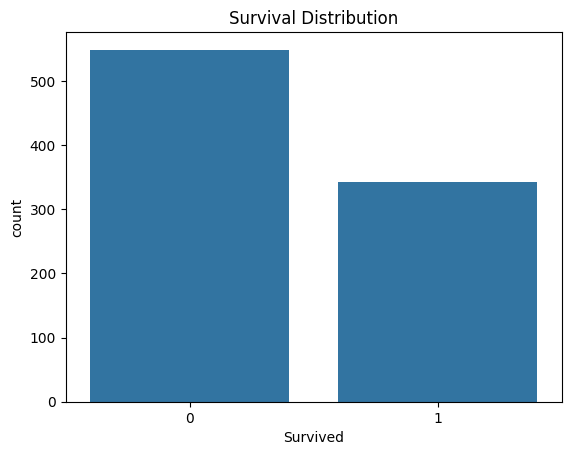

In [8]:
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution')
plt.show()


Drop Irrelevant / High-Cardinality Columns

In [9]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)


In [10]:
df.isnull().sum()


,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [12]:
df['Age'] = df['Age'].fillna(df['Age'].median())


In [13]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


In [14]:
df.isnull().sum()


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


### Data Cleaning and Preprocessing

Irrelevant columns such as PassengerId, Name, Ticket, and Cabin were removed
to reduce noise and complexity.

Missing values in the Age column were filled
using the median, while missing values in Embarked were filled using the mode.


This ensured the dataset contained no missing values before model training.


### Exploratory Data Analysis

- The dataset contains both numerical and categorical variables.
- Missing values are present in Age, Cabin, and Embarked columns.
- The target variable `Survived` is slightly imbalanced, with more non-survivors than survivors.
- Several columns such as Name and Ticket are non-numeric and require preprocessing.


Encode categorical variables (e.g., Sex, Embarked)

In [15]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


### Encoding Categorical Variables

Categorical variables such as Sex and Embarked were encoded using Label Encoding
to convert textual categories into numerical values. This step is necessary
because Naive Bayes classifiers require numerical input features.


Split the dataset into training and testing sets.

In [16]:
X = df.drop('Survived', axis=1)
y = df['Survived']
X.head(), y.head()


(   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
 0       3    1  22.0      1      0   7.2500         2
 1       1    0  38.0      1      0  71.2833         0
 2       3    0  26.0      0      0   7.9250         2
 3       1    0  35.0      1      0  53.1000         2
 4       3    1  35.0      0      0   8.0500         2,
 0    0
 1    1
 2    1
 3    1
 4    0
 Name: Survived, dtype: int64)

### Feature and Target Split

The dataset was divided into input features (X) and the target variable (y).
The target variable `Survived` indicates whether a passenger survived the
Titanic disaster, while the remaining columns were used as predictive features.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


### Train–Test Split

The dataset was split into training and testing sets using an 80–20 ratio.
Stratified sampling was applied to preserve the original class distribution
of the target variable, ensuring reliable model evaluation.


Implement the Naive Bayes classifier to predict passenger survival.

In [18]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


GaussianNB()

### Naive Bayes Model Training

A Gaussian Naive Bayes classifier was used due to the presence of continuous
numerical features such as Age and Fare. The model was trained using the
training dataset to learn class-conditional probability distributions.


Evaluate the model using metrics like accuracy, confusion matrix, and classification report.

In [19]:
y_pred = nb_model.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7821229050279329

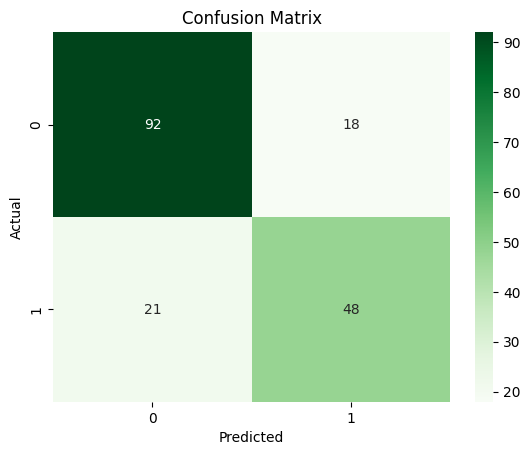

In [21]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [22]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.81      0.84      0.83       110
           1       0.73      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



### Model Evaluation

The Naive Bayes model was evaluated using accuracy, confusion matrix, and
classification report. The results indicate that the model performs well
as a baseline classifier, with balanced precision and recall for both classes.


Provide a brief analysis of your findings and insights.

### Final Analysis & Insights

The Naive Bayes classifier achieved an accuracy of approximately 78% on the
Titanic test dataset. Despite its strong assumption that features are
independent, the model performed well as a baseline classifier.

Categorical features such as Sex and Embarked played a significant role in
predicting survival, while numerical features like Age and Fare also
contributed meaningfully. The confusion matrix and classification report
indicate a reasonable balance between precision and recall for both classes.

Overall, Naive Bayes proved to be a fast, simple, and effective probabilistic
model for predicting passenger survival on the Titanic dataset.
